In [1]:
import os
import gc
import time
import sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
print("Hi, I'm loading the libraries...")
try:
    import cupy as cp
    GPU_AVAILABLE = True
    mempool = cp.get_default_memory_pool()
    print(f"GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except ImportError:
    GPU_AVAILABLE = False
    print("CuPy not found — CPU only")

Hi, I'm loading the libraries...
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
def bytes_human(n):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024.0

def show_cwt_map(coeff, title=None, pclip=(1, 99)):
    if GPU_AVAILABLE and isinstance(coeff, cp.ndarray):
        coeff = cp.asnumpy(coeff)
    mag = np.abs(coeff).astype(np.float32)
    viz = np.log1p(mag)
    vmin, vmax = np.percentile(viz, pclip)
    plt.figure(figsize=(12, 6))
    plt.imshow(viz, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label="log(1+|coeff|)")
    if title:
        plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

def cwt2_gpu(X_np, sigmas, keep_last=False):
    H, W = X_np.shape
    timings = []
    last_coeff = None

    # Transfer to GPU
    t0 = time.perf_counter()
    X_gpu = cp.asarray(X_np, dtype=cp.float32)
    cp.cuda.Stream.null.synchronize()
    timings.append(("CPU→GPU transfer", time.perf_counter() - t0))

    # Forward FFT
    t0 = time.perf_counter()
    F = cp.fft.rfft2(X_gpu)
    cp.cuda.Stream.null.synchronize()
    timings.append(("rfft2_forward", time.perf_counter() - t0))

    del X_gpu
    mempool.free_all_blocks()

    # Frequency grids — ALL on GPU using CuPy
    ky = (2 * cp.pi) * cp.fft.fftfreq(H).astype(cp.float32)
    kx = (2 * cp.pi) * cp.fft.rfftfreq(W).astype(cp.float32)
    k2 = ky[:, None] ** 2 + kx[None, :] ** 2

    # Pre-allocate on GPU
    psi_hat = cp.empty_like(k2)
    Ff = cp.empty_like(F)

    for s in sigmas:
        s = float(s)
        t1 = time.perf_counter()

        cp.multiply(-0.5 * s * s, k2, out=psi_hat)
        cp.exp(psi_hat, out=psi_hat)
        cp.multiply(k2, psi_hat, out=psi_hat)
        cp.multiply(F, psi_hat, out=Ff)

        coeff = cp.fft.irfft2(Ff, s=(H, W))
        cp.cuda.Stream.null.synchronize()

        dt = time.perf_counter() - t1
        timings.append((f"scale_{s}", dt))

        if keep_last:
            last_coeff = coeff
        else:
            del coeff
        mempool.free_all_blocks()

    del F, k2, psi_hat, Ff
    mempool.free_all_blocks()
    return timings, last_coeff

def cwt2_cpu(X, sigmas, keep_last=False):
    from scipy.fft import rfft2, irfft2, fftfreq, rfftfreq

    H, W = X.shape
    X = np.ascontiguousarray(X, dtype=np.float32)
    timings = []
    last_coeff = None
    workers = os.cpu_count() or 1

    t0 = time.perf_counter()
    F = rfft2(X, workers=workers)
    timings.append(("rfft2_forward", time.perf_counter() - t0))

    ky = (2 * np.pi) * fftfreq(H, d=1.0).astype(np.float32)
    kx = (2 * np.pi) * rfftfreq(W, d=1.0).astype(np.float32)
    k2 = ky[:, None] ** 2 + kx[None, :] ** 2

    psi_hat = np.empty_like(k2)
    Ff = np.empty_like(F)

    for s in sigmas:
        s = float(s)
        t1 = time.perf_counter()

        np.multiply(-0.5 * s * s, k2, out=psi_hat)
        np.exp(psi_hat, out=psi_hat)
        np.multiply(k2, psi_hat, out=psi_hat)
        np.multiply(F, psi_hat, out=Ff)

        coeff = irfft2(Ff, s=(H, W), workers=workers)
        dt = time.perf_counter() - t1
        timings.append((f"scale_{s}", dt))

        if keep_last:
            last_coeff = coeff.astype(np.float32, copy=False)
        else:
            del coeff
        gc.collect()

    return timings, last_coeff

In [3]:
with h5py.File("DF__UTC_20201113_070532.602.h5", "r") as f:
    arr = f["/Acoustic"][()]
    print(f"Raw shape: {arr.shape}")

X = np.ascontiguousarray(arr.T, dtype=np.float32)
print(f"Prepared shape: {X.shape}")
print(f"Memory: {bytes_human(X.nbytes)}")
del arr
gc.collect()

Raw shape: (30000, 6912)
Prepared shape: (6912, 30000)
Memory: 791.0 MB


0

GPU BENCHMARK
      CPU→GPU transfer: 2.9934 s
         rfft2_forward: 0.7307 s
            scale_32.0: 4.2030 s
                 TOTAL: 11.0930 s


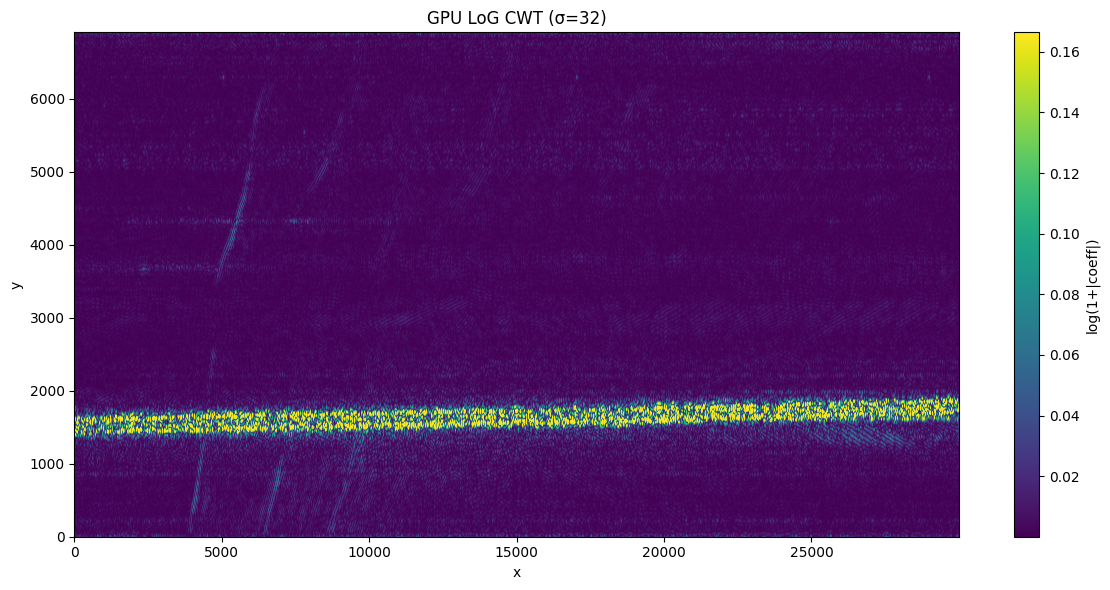

In [4]:
scales = [32]

print("GPU BENCHMARK")
t1 = time.perf_counter()
timings, coeff_gpu = cwt2_gpu(X, scales, keep_last=True)
t_total = time.perf_counter() - t1

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'TOTAL':>20}: {t_total:.4f} s")

show_cwt_map(coeff_gpu, title=f"GPU LoG CWT (σ=32)")

In [ ]:
print("CPU BENCHMARK")
t1 = time.perf_counter()
timings, coeff_cpu = cwt2_cpu(X, scales, keep_last=True)
t_total = time.perf_counter() - t1

for label, dt in timings:
    print(f"  {label:>20}: {dt:.4f} s")
print(f"  {'TOTAL':>20}: {t_total:.4f} s")

show_cwt_map(coeff_cpu, title=f"CPU LoG CWT (σ=32)")

CPU BENCHMARK
         rfft2_forward: 14.5793 s
            scale_32.0: 7.1884 s
                 TOTAL: 22.4531 s
